# Elmer Capacitance Extraction of an Interdigital Capacitor

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra and the Elmer driver from `gplugins`:

```bash
uv add "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@c3372b97a50cda44043603f80c955edcf028a7fb"
# or with pip:
pip install "qpdk[models]" "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@c3372b97a50cda44043603f80c955edcf028a7fb"
```

The Elmer driver changes are currently in the companion
[gplugins pull request](https://github.com/gdsfactory/gplugins/pull/781); the install
commands pin the revision tested with this notebook until a release includes it.

**Elmer is an external solver.** `ElmerGrid` and `ElmerSolver` must be available on your
`PATH`; `ElmerSolver_mpi` is also needed when `QPDK_ELMER_PROCESSES` exceeds 1. They
are not pip-installable. See the
[Elmer FEM installation guide](https://www.elmerfem.org/blog/binaries/) for binaries and
container options.

See the {ref}`extras reference <notebook-extras>` for what each qpdk extra installs.
::::

This notebook runs a quasi-static electrostatic solve with Elmer FEM for two
interdigital terminals surrounded by a finite grounded M1 region. Elmer solves
$\nabla \cdot (\epsilon \nabla \phi) = 0$ with a fixed potential on each metal
terminal. Elmer's `.dat` result is the lumped (circuit) capacitance matrix;
`gplugins` converts it to a Maxwell matrix, with negative off-diagonal entries, in
`ElectrostaticResults`.

The reported number comes from a mesh-convergence study. The geometry, the layer stack
and the simulation domain are held fixed, the mesh is refined over five factors, and
the finest mesh supplies the final value. A separate lateral-pad comparison checks how
much that value depends on the outer boundary of the finite domain.

The saved output uses cubic elements and a 0.5 % refinement check. CI separately
executes the notebook with quadratic elements and a 3 % check when `GITHUB_ACTIONS`
is set. Set `QPDK_ELMER_CI_FAST=1` to use that profile locally. The cubic
profile is memory intensive; use the CI smoke profile for a quick functional run.

## Physics

An interdigital capacitor (IDC) is two interleaved combs of metal fingers. Each comb is
a separate terminal. A nearby M1 region is a third conductor held at zero potential.
We extract the terminal-to-terminal coupling and each terminal's capacitance to ground.

For $N$ conductors Elmer's `.dat` result is the lumped (circuit) capacitance
matrix. `gplugins` converts it to the Maxwell form $C$ reported in
`ElectrostaticResults`, defined by $Q_i = \sum_j C_{ij} V_j$ with negative
off-diagonal entries:

$$ C_{ij} = -C_{ij}^{\text{mutual}} \quad (i \neq j). $$

With the ground fixed at zero, the reduced two-terminal matrix has
$C_{12}^{\text{mutual}} = -C_{12}$ and
$C_{1\text{g}} = C_{11} + C_{12}$,
$C_{2\text{g}} = C_{22} + C_{21}$. Thus each diagonal includes coupling to the
other terminal and to ground. All Elmer output is in SI units (farads); we convert
to femtofarads below.

This is a 3D FEM result only. It is **not benchmarked against an analytic IDC model**,
and no analytic formula is evaluated here. The check below compares the last two
mesh results; their difference is not a bound on absolute model error.

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
        "gplugins[elmer] @ git+https://github.com/gdsfactory/gplugins.git@c3372b97a50cda44043603f80c955edcf028a7fb",
    ])

In [2]:
# CI executes this notebook headless with MPLBACKEND=Agg, which would drop the
# convergence figure from the saved output, so pin the backend that renders figures
# inline.
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

In [3]:
import os
import tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import gdsfactory as gf
import numpy as np
from gplugins.elmer import run_capacitive_simulation_elmer
from matplotlib import font_manager, pyplot as plt
from matplotlib.patches import Patch, Polygon as MplPolygon
from meshwell.resolution import ConstantInField

from qpdk import PDK
from qpdk.cells.capacitor import interdigital_capacitor
from qpdk.config import PATH
from qpdk.tech import LAYER, material_properties

PDK.activate()

In [4]:
for style_source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
    try:
        plt.style.use(style_source)
    except OSError:
        continue
    break

for font_path in (PATH.repo / "build" / "docs-fonts").glob("*"):
    if font_path.suffix.lower() in {".otf", ".ttf"}:
        font_manager.fontManager.addfont(str(font_path))

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [
    name
    for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
    if name in installed_fonts
] + ["sans-serif"]

try:
    from IPython import get_ipython

    if get_ipython() is not None:
        from matplotlib_inline.backend_inline import set_matplotlib_formats

        plt.rcParams["svg.fonttype"] = "path"
        set_matplotlib_formats("svg", "png")
except ImportError:
    pass  # Plain Python runs do not need IPython display formats.

## Simulation Geometry

We use the QPDK `interdigital_capacitor` geometry with
a small number of fingers to keep the mesh and solve affordable.

![Two isolated IDC combs inside a grounded M1 frame and finite dielectric domain](figures/elmer-idc-ground.svg)

Three details matter for a valid capacitance extraction:

1. **Two isolated terminals.** The capacitor must present two disconnected metal
   polygons. QPDK's IDC draws its metal on `M1_DRAW` (the additive mask). We omit its
   default local etch rectangle so the two combs remain separate.
2. **Grounded chip metal.** A disconnected M1 frame surrounds the combs across a
   10 µm etched clearance. We draw it on `M1_DRAW` and etch the full simulation
   outline. QPDK's derived `M1` rule, `SIM_AREA - (M1_ETCH - M1_DRAW)`, then leaves
   exactly the two ported combs and the unported frame. The Elmer driver grounds
   unported conductors. The frame's outer edge stays fixed 45 µm from the IDC.
3. **A domain outline for the dielectrics.** The substrate and air prisms are built from
   the same outline on the non-fabrication `SIM_AREA` layer.

The lateral pad is fixed for the whole study at `domain_pad=90.0` μm, which puts the
outer boundary beyond the fixed ground frame. The outer substrate and vacuum faces
use Elmer's natural zero-normal-flux boundary condition, so
the finite domain still affects the extracted value; the lateral-pad comparison below
quantifies that effect separately from mesh convergence.

findfont: Failed to find font weight bold, now using 400.


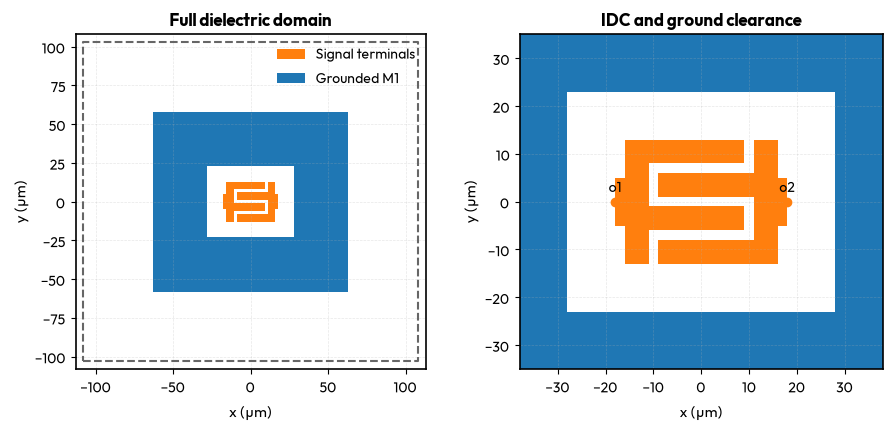

Bounding box: (-108,-103;108,103)
Terminals: ['o1', 'o2']


In [5]:
@gf.cell
def interdigital_capacitor_for_elmer(
    fingers: int = 4,
    finger_length: float = 20.0,
    finger_gap: float = 2.0,
    thickness: float = 5.0,
    ground_clearance: float = 10.0,
    ground_outer_pad: float = 45.0,
    domain_pad: float = 90.0,
) -> gf.Component:
    """Two-terminal IDC with a separate grounded M1 frame.

    Args:
        fingers: Total number of interleaved fingers.
        finger_length: Length of each finger in μm.
        finger_gap: Gap between adjacent fingers in μm.
        thickness: Finger width in μm.
        ground_clearance: Etched clearance from the IDC bounding box to ground in μm.
        ground_outer_pad: Outer edge of the grounded frame from the IDC in μm.
        domain_pad: Lateral padding of the dielectric simulation domain in μm.

    Returns:
        Component with two ported combs, one unported M1 ground frame, and a
        `SIM_AREA` outline for the dielectric domain.

    Raises:
        ValueError: If the ground clearance, ground extent, and domain are not nested.
    """
    if not 0 < ground_clearance < ground_outer_pad < domain_pad:
        raise ValueError("Require 0 < ground_clearance < ground_outer_pad < domain_pad")

    c = gf.Component()
    idc = c << interdigital_capacitor(
        fingers=fingers,
        finger_length=finger_length,
        finger_gap=finger_gap,
        thickness=thickness,
        etch_layer=None,  # keep the two combs as separate M1_DRAW polygons
    )
    c.add_ports(idc.ports)

    c.flatten()
    device = c.bbox()
    ground_inner = device.enlarged(ground_clearance, ground_clearance)
    ground_outer = device.enlarged(ground_outer_pad, ground_outer_pad)
    domain = device.enlarged(domain_pad, domain_pad)
    ground_sections = (
        (
            ground_outer.left,
            ground_outer.bottom,
            ground_outer.right,
            ground_inner.bottom,
        ),
        (ground_outer.left, ground_inner.top, ground_outer.right, ground_outer.top),
        (ground_outer.left, ground_inner.bottom, ground_inner.left, ground_inner.top),
        (ground_inner.right, ground_inner.bottom, ground_outer.right, ground_inner.top),
    )
    for section in ground_sections:
        c.kdb_cell.shapes(LAYER.M1_DRAW).insert(gf.kdb.DBox(*section))
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(domain)
    c.kdb_cell.shapes(LAYER.M1_ETCH).insert(domain)
    return c


component = interdigital_capacitor_for_elmer()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ground_color, signal_color = colors[:2]
metal_shapes = []
for polygon in component.get_polygons(by="name", layers=[LAYER.M1_DRAW])["M1_DRAW"]:
    metal = polygon.to_dtype(component.kcl.dbu)
    vertices = [(point.x, point.y) for point in metal.each_point_hull()]
    is_signal = any(
        metal.bbox().contains(gf.kdb.DPoint(*port.center)) for port in component.ports
    )
    metal_shapes.append((vertices, is_signal))

_, (ax_domain, ax_device) = plt.subplots(1, 2, figsize=(9.0, 4.2), layout="constrained")
for ax in (ax_domain, ax_device):
    for vertices, is_signal in metal_shapes:
        ax.add_patch(
            MplPolygon(
                vertices,
                facecolor=signal_color if is_signal else ground_color,
                edgecolor="none",
            )
        )
    ax.set_aspect("equal")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")

domain = component.bbox()
ax_domain.plot(
    [domain.left, domain.right, domain.right, domain.left, domain.left],
    [domain.bottom, domain.bottom, domain.top, domain.top, domain.bottom],
    linestyle="--",
    color="0.4",
)
ax_domain.set_xlim(domain.left - 5, domain.right + 5)
ax_domain.set_ylim(domain.bottom - 5, domain.top + 5)
ax_domain.set_title("Full dielectric domain")
ax_domain.legend(
    handles=[
        Patch(facecolor=signal_color, label="Signal terminals"),
        Patch(facecolor=ground_color, label="Grounded M1"),
    ],
    loc="upper right",
)

ax_device.set_xlim(-38, 38)
ax_device.set_ylim(-35, 35)
ax_device.set_title("IDC and ground clearance")
for port in component.ports:
    ax_device.plot(*port.center, marker="o", color=signal_color)
    ax_device.annotate(
        port.name,
        port.center,
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
    )
plt.show()
print(f"Bounding box: {component.bbox()}")
print(f"Terminals: {[port.name for port in component.ports]}")

## Layer Stack and Materials

We start from `PDK.layer_stack`, which the Palace capacitor optimization notebook
also uses. We retain the three levels needed here, including the derived `M1` rule.
The PDK specifies the Nb film thickness and material. We reduce the substrate and
vacuum heights to $60\,\text{μm}$ and $40\,\text{μm}$ for this finite simulation
domain; both are $500\,\text{μm}$ in the full PDK stack. The vacuum starts at the
substrate surface to fill the gaps beside
the film; [meshwell](https://github.com/simbilod/meshwell) cuts the higher-priority
metal out of that prism. We check lateral-domain sensitivity below, but do not
quantify the effect of these vertical truncations.

Material permittivities come from the QPDK technology definition
(`qpdk.tech.material_properties`): Si uses $\epsilon_{\text{r}} = 11.45$, and the niobium
film is treated as a perfect conductor.

In [6]:
layer_stack = PDK.layer_stack.model_copy(deep=True)
layer_stack.layers = {
    name: layer_stack.layers[name] for name in ("M1", "Substrate", "Vacuum")
}
layer_stack.layers["Substrate"].zmin = -60.0
layer_stack.layers["Substrate"].thickness = 60.0
layer_stack.layers["Vacuum"].zmin = 0.0
layer_stack.layers["Vacuum"].thickness = 40.0

material_spec = material_properties

print("Layer stack:")
for name, level in layer_stack.layers.items():
    print(
        f"  {name:>9}: z = {level.zmin:+.2f} … {level.zmin + level.thickness:+.2f} µm, "
        f"material = {level.material}"
    )

Layer stack:
         M1: z = +0.00 … +0.20 µm, material = Nb
  Substrate: z = -60.00 … +0.00 µm, material = Si
     Vacuum: z = +0.00 … +40.00 µm, material = vacuum


## Mesh Settings

`mesh_parameters` is forwarded to [meshwell's mesh function](https://simbilod.github.io/meshwell/02_intro_meshwell.html#cad-mesh).
Its [`resolution_specs` API](https://simbilod.github.io/meshwell/21_resolution_advanced.html)
maps each physical prism name to a list of resolution objects. The driver splits
the ported metal into `M1@o1` and `M1@o2`; the unported `M1` frame is ground.
[`ConstantInField`](https://simbilod.github.io/meshwell/20_resolution_basic.html)
pins an element size. The terminal surfaces resolve the 2 µm finger gaps, while
ground edges and the bulk dielectric can be coarser.

`BASE_MESH_LENGTHS_UM` holds the nominal (factor 1.0) lengths, and
`mesh_parameters_for_factor` scales every one of them by the same factor: a smaller
factor refines the whole mesh uniformly, while the geometry, the layer stack and the
domain stay untouched.

In [7]:
BASE_MESH_LENGTHS_UM = {
    "default": 8.0,  # μm, everywhere not covered by a more specific spec
    "terminal": 0.5,  # μm, terminal edges and faces
    "ground_edges": 2.0,  # μm, boundary of the grounded M1 frame
    "dielectric_surfaces": 3.0,  # μm, substrate and vacuum interfaces
    "dielectric_volumes": 8.0,  # μm, substrate and vacuum bulk
}


def mesh_parameters_for_factor(mesh_factor: float) -> dict[str, Any]:
    """Mesh parameters with every base length scaled by ``mesh_factor``.

    Args:
        mesh_factor: Multiplier applied to all mesh lengths. ``1.0`` is the nominal
            mesh, smaller values refine it.

    Returns:
        Keyword arguments for :func:`meshwell.mesh.mesh`.

    Raises:
        ValueError: If ``mesh_factor`` is not positive.
    """
    if not mesh_factor > 0:
        raise ValueError(f"mesh_factor must be positive, got {mesh_factor}")

    scaled = {
        name: length * mesh_factor for name, length in BASE_MESH_LENGTHS_UM.items()
    }
    resolution_specs: dict[str, list[ConstantInField]] = {}
    for terminal in ("M1@o1", "M1@o2"):
        resolution_specs[terminal] = [
            ConstantInField(resolution=scaled["terminal"], apply_to="curves"),
            ConstantInField(resolution=scaled["terminal"], apply_to="surfaces"),
        ]
    resolution_specs["M1"] = [
        ConstantInField(resolution=scaled["ground_edges"], apply_to="curves")
    ]
    for dielectric in ("Substrate", "Vacuum"):
        resolution_specs[dielectric] = [
            ConstantInField(
                resolution=scaled["dielectric_surfaces"], apply_to="surfaces"
            ),
            ConstantInField(
                resolution=scaled["dielectric_volumes"], apply_to="volumes"
            ),
        ]
    return {
        "default_characteristic_length": scaled["default"],
        "resolution_specs": resolution_specs,
        "background_tag": "Vacuum",
    }


nominal_mesh = mesh_parameters_for_factor(1.0)
print(
    f"Nominal default characteristic length: "
    f"{nominal_mesh['default_characteristic_length']:.2f} µm"
)
for prism, specs in nominal_mesh["resolution_specs"].items():
    sizes = ", ".join(f"{spec.resolution:.2f} µm ({spec.apply_to})" for spec in specs)
    print(f"  {prism:>10}: {sizes}")

Nominal default characteristic length: 8.00 µm
       M1@o1: 0.50 µm (curves), 0.50 µm (surfaces)
       M1@o2: 0.50 µm (curves), 0.50 µm (surfaces)
          M1: 2.00 µm (curves)
   Substrate: 3.00 µm (surfaces), 8.00 µm (volumes)
      Vacuum: 3.00 µm (surfaces), 8.00 µm (volumes)


## Solve at Each Mesh Factor

Every solve below uses the same component, layer stack, materials and domain; only the
mesh factor changes. The run profile controls these settings:

- Finite element order is the polynomial degree of the basis used to approximate the
  potential within an element; see [MFEM's basis-function reference](https://mfem.org/basis-functions/).
  The saved study uses cubic (`element_order=3`) functions; CI uses quadratic
  (`element_order=2`). A
  first-order solve on a coarse mesh is not a reliable capacitance number.
- `QPDK_ELMER_PROCESSES` selects MPI ranks for the default profile (1 by default).
  CI runs serially.
- The default profile raises the linear-iteration cap to 3500: the cubic basis needs more
  iterations per solve than the driver's default of 500, which CI keeps.

`solve_idc` runs one solve into a fresh scratch directory and returns the reduced
Maxwell matrix in fF. Each comb carries a port; the separate unported M1 frame is
fixed at zero potential.

In [8]:
IS_CI = (
    os.environ.get("GITHUB_ACTIONS") == "true"
    or os.environ.get("QPDK_ELMER_CI_FAST") == "1"
)
RUN_MODE = "CI smoke" if IS_CI else "high accuracy"
MESH_FACTORS = (1.0, 0.75, 0.6, 0.5) if IS_CI else (0.5, 0.4, 0.35, 0.3, 0.25)
ELEMENT_ORDER = 2 if IS_CI else 3
CONVERGENCE_TOLERANCE = 0.03 if IS_CI else 0.005
MAX_LINEAR_ITERATIONS = 500 if IS_CI else 3500
N_PROCESSES = 1 if IS_CI else int(os.environ.get("QPDK_ELMER_PROCESSES", "1"))

print(
    f"Elmer notebook run mode: {RUN_MODE} "
    f"(element_order={ELEMENT_ORDER}, "
    f"tolerance={100 * CONVERGENCE_TOLERANCE:.1f} %, "
    f"n_processes={N_PROCESSES})"
)


@dataclass(slots=True, frozen=True)
class MeshSolve:
    """One independently remeshed electrostatic solve."""

    label: str
    mesh_factor: float
    capacitance_ff: np.ndarray
    mutual_ff: float

    @property
    def ground_ff(self) -> np.ndarray:
        """Capacitance from each terminal to the grounded M1 frame in fF."""
        return self.capacitance_ff.sum(axis=1)


def solve_idc(component: gf.Component, mesh_factor: float, label: str) -> MeshSolve:
    """Solve the capacitor on a mesh scaled by ``mesh_factor``.

    Args:
        component: Two-terminal IDC with an unported ground and `SIM_AREA` outline.
        mesh_factor: Multiplier on every base mesh length; smaller is finer.
        label: Name for this solve, used in tables and error messages.

    Returns:
        The reduced Maxwell matrix in fF, mutual coupling, and ground coupling.

    Raises:
        ValueError: If the component ports are not named ``o1`` and ``o2``.
    """
    simulation_folder = Path(
        tempfile.mkdtemp(prefix="qpdk_elmer_interdigital_capacitor_")
    )
    print(f"{label}: solving")
    results = run_capacitive_simulation_elmer(
        component,
        element_order=ELEMENT_ORDER,
        n_processes=N_PROCESSES,
        layer_stack=layer_stack,
        material_spec=material_spec,
        simulation_folder=simulation_folder,
        mesh_parameters=mesh_parameters_for_factor(mesh_factor),
        simulator_params={"linear_system_max_iterations": MAX_LINEAR_ITERATIONS},
    )

    terminals = tuple(port.name for port in component.ports)
    if terminals != ("o1", "o2"):
        raise ValueError(f"{label}: unexpected terminals {terminals}")
    capacitance_ff = (
        np.array([
            [results.capacitance_matrix[i, j] for j in terminals] for i in terminals
        ])
        * 1e15
    )  # F -> fF
    return MeshSolve(
        label=label,
        mesh_factor=mesh_factor,
        capacitance_ff=capacitance_ff,
        mutual_ff=-float(capacitance_ff[0, 1]),
    )

Elmer notebook run mode: high accuracy (element_order=3, tolerance=0.5 %, n_processes=32)


In [9]:
mesh_results = [
    solve_idc(component, factor, f"mesh factor {factor:g}") for factor in MESH_FACTORS
]

mesh factor 0.5: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.4: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.35: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.3: solving
MAIN: *** Elmer Solver: ALL DONE ***
mesh factor 0.25: solving
MAIN: *** Elmer Solver: ALL DONE ***


## Capacitance Matrix

The reduced Maxwell matrix is assembled in port order, so its rows and columns
are `o1` and `o2` while the unported ground is held at zero. The final values
come from the finest mesh, the last element of `mesh_results`.

In [10]:
finest = mesh_results[-1]
terminals = tuple(port.name for port in component.ports)

print("Final Maxwell capacitance matrix (fF):")
print(finest.capacitance_ff)
print(f"\nCapacitance matrix indexed by {terminals}")

Final Maxwell capacitance matrix (fF):
[[10.8269732  -5.70786783]
 [-5.70786783 10.82559906]]

Capacitance matrix indexed by ('o1', 'o2')


The off-diagonal entry gives mutual coupling as $-C_{12}$. The diagonal entries
include coupling to both the other terminal and ground. Their row sums give the
separate ground capacitances $C_{1\text{g}}$ and $C_{2\text{g}}$.

In [11]:
print(f"Final off-diagonal C12: {finest.capacitance_ff[0, 1]:.3f} fF")
print(f"Final mutual capacitance C12_mutual = -C12: {finest.mutual_ff:.3f} fF")
print(f"Final terminal o1 to ground: {finest.ground_ff[0]:.3f} fF")
print(f"Final terminal o2 to ground: {finest.ground_ff[1]:.3f} fF")
print(
    f"Final reported mutual capacitance: {finest.mutual_ff:.3f} fF "
    f"(element_order={ELEMENT_ORDER}, mesh factor {finest.mesh_factor:g})"
)

Final off-diagonal C12: -5.708 fF
Final mutual capacitance C12_mutual = -C12: 5.708 fF
Final terminal o1 to ground: 5.119 fF
Final terminal o2 to ground: 5.118 fF
Final reported mutual capacitance: 5.708 fF (element_order=3, mesh factor 0.25)


## Mesh Convergence

The five saved solves are **independent remeshes**, not Elmer nonlinear iteration
counts: their factors are 0.5, 0.4, 0.35, 0.3 and 0.25. CI uses the coarser
factors 1.0, 0.75, 0.6 and 0.5. Nothing is continued from one solve to the next, and no field
solution is reused, so the pass number is only an index into the refinement sequence.

The upper panel shows mutual and terminal-to-ground capacitances. The lower panel
shows the largest relative change among those three quantities from the previous
pass. The last two changes must stay below `CONVERGENCE_TOLERANCE` (0.5 % in the
saved run, 3 % in CI). This is a refinement check, not an absolute error bound;
independent remeshes need not change the result monotonically.

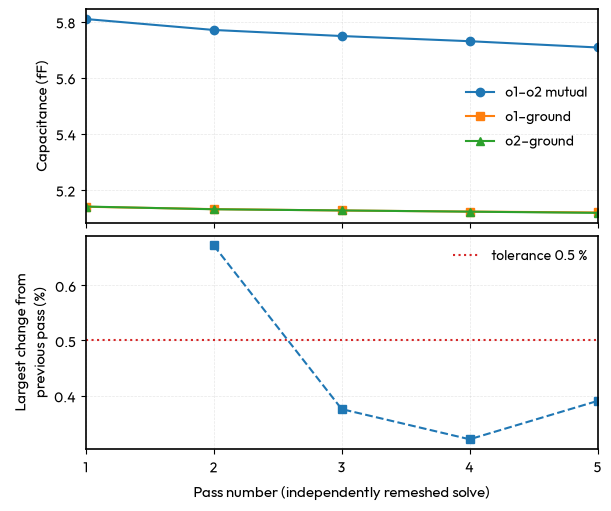

pass  factor  mutual_fF o1-ground_fF o2-ground_fF max_change_pct
   1     0.5      5.809        5.140        5.140            n/a
   2     0.4      5.770        5.131        5.131          0.672
   3    0.35      5.749        5.126        5.126          0.376
   4     0.3      5.730        5.122        5.122          0.321
   5    0.25      5.708        5.119        5.118          0.390
Mesh convergence check passed: final changes 0.321 % and 0.390 % <= tolerance 0.5 %


In [12]:
passes = np.arange(1, len(mesh_results) + 1)
capacitances_ff = np.array([
    [result.mutual_ff, *result.ground_ff] for result in mesh_results
])
relative_change = np.full_like(capacitances_ff, np.nan)
relative_change[1:] = np.abs(np.diff(capacitances_ff, axis=0)) / capacitances_ff[:-1]
max_change = np.max(relative_change[1:], axis=1)

_, (ax_value, ax_change) = plt.subplots(
    2, 1, sharex=True, figsize=(6.0, 5.0), layout="constrained"
)
for column, label, marker in zip(
    range(3), ("o1–o2 mutual", "o1–ground", "o2–ground"), ("o", "s", "^"), strict=True
):
    ax_value.plot(passes, capacitances_ff[:, column], marker=marker, label=label)
ax_value.set_ylabel("Capacitance (fF)")
ax_value.legend()

ax_change.plot(passes[1:], 100 * max_change, marker="s", linestyle="--")
ax_change.axhline(
    100 * CONVERGENCE_TOLERANCE,
    color="tab:red",
    linestyle=":",
    label=f"tolerance {100 * CONVERGENCE_TOLERANCE:.1f} %",
)
ax_change.set_xticks(passes)
ax_change.set_xlabel("Pass number (independently remeshed solve)")
ax_change.set_ylabel("Largest change from\nprevious pass (%)")
ax_change.legend()
plt.show()

print(
    f"{'pass':>4} {'factor':>7} {'mutual_fF':>10} "
    f"{'o1-ground_fF':>12} {'o2-ground_fF':>12} {'max_change_pct':>14}"
)
for index, result in enumerate(mesh_results, start=1):
    change_text = "n/a" if index == 1 else f"{100 * max_change[index - 2]:.3f}"
    print(
        f"{index:>4} {result.mesh_factor:>7g} {result.mutual_ff:>10.3f} "
        f"{result.ground_ff[0]:>12.3f} {result.ground_ff[1]:>12.3f} "
        f"{change_text:>14}"
    )

final_changes = max_change[-2:]
if not (final_changes <= CONVERGENCE_TOLERANCE).all():
    raise ValueError(
        f"the last two mesh refinements changed a capacitance by "
        f"{100 * final_changes[0]:.3f} % and {100 * final_changes[1]:.3f} %, "
        f"above CONVERGENCE_TOLERANCE = "
        f"{100 * CONVERGENCE_TOLERANCE:.1f} %; refine the mesh further"
    )
print(
    f"Mesh convergence check passed: final changes "
    f"{100 * final_changes[0]:.3f} % and {100 * final_changes[1]:.3f} % "
    f"<= tolerance {100 * CONVERGENCE_TOLERANCE:.1f} %"
)

## Lateral Domain Sensitivity

Mesh convergence above holds the domain fixed at `domain_pad=90.0` μm. This separate
check asks how much the three reported capacitances depend on the outer boundary:
we rebuild the same capacitor with a 60 μm lateral pad, keep the ground frame,
element order, and finest mesh factor fixed, and compare against the pad-90 μm
result from the final pass.

Changing the pad also changes the mesh, so the difference mixes the domain effect with
a discretization effect. This is a sensitivity check between two finite domains: it is
**not** a proof that the 90 μm boundary is converged to an infinite domain, and it says
nothing about vertical truncation or absolute accuracy.

In [13]:
component_narrow = interdigital_capacitor_for_elmer(domain_pad=60.0)
narrow = solve_idc(component_narrow, finest.mesh_factor, "pad 60 μm, finest mesh")
wide = finest

quantities = ("mutual", "o1–ground", "o2–ground")
narrow_values = np.array([narrow.mutual_ff, *narrow.ground_ff])
wide_values = np.array([wide.mutual_ff, *wide.ground_ff])
domain_change = np.abs(wide_values - narrow_values) / narrow_values
for label, small, large, change in zip(
    quantities, narrow_values, wide_values, domain_change, strict=True
):
    print(
        f"{label}: pad 60 = {small:.3f} fF, pad 90 = {large:.3f} fF, change = {change:.2%}"
    )
if domain_change.max() > 0.01:
    raise ValueError(
        f"lateral-pad check changed capacitance by {domain_change.max():.2%}"
    )
print("Lateral-domain sensitivity check passed: change <= 1 %")

pad 60 μm, finest mesh: solving
MAIN: *** Elmer Solver: ALL DONE ***
mutual: pad 60 = 5.714 fF, pad 90 = 5.708 fF, change = 0.11%
o1–ground: pad 60 = 5.113 fF, pad 90 = 5.119 fF, change = 0.12%
o2–ground: pad 60 = 5.114 fF, pad 90 = 5.118 fF, change = 0.08%
Lateral-domain sensitivity check passed: change <= 1 %


## Sanity Checks

Every solve must give a finite, symmetric Maxwell matrix with a positive diagonal,
negative off-diagonal, and positive row sums. Those row sums are the capacitances
to the grounded M1 frame. The broad 5-40 fF mutual range is a regression guard
against order-of-magnitude errors, not a claim about model accuracy.

In [14]:
for result in (*mesh_results, narrow):
    matrix = result.capacitance_ff
    if not np.isfinite(matrix).all():
        raise ValueError(f"{result.label}: matrix has non-finite entries")
    if not np.allclose(matrix, matrix.T, rtol=1e-2, atol=1e-3):
        raise ValueError(f"{result.label}: matrix is not symmetric")
    if not (np.diag(matrix) > 0).all():
        raise ValueError(f"{result.label}: matrix diagonal must be positive")
    if matrix[0, 1] >= 0 or matrix[1, 0] >= 0:
        raise ValueError(f"{result.label}: Maxwell off-diagonals must be negative")
    if not 5.0 < result.mutual_ff < 40.0:
        raise ValueError(
            f"{result.label}: mutual capacitance outside 5-40 fF: {result.mutual_ff}"
        )
    if not (result.ground_ff > 0).all():
        raise ValueError(
            f"{result.label}: terminal-to-ground capacitance must be positive"
        )

print("All checks passed.")

All checks passed.


## Summary

The saved notebook reports the quasi-static capacitance of a grounded QPDK
interdigital capacitor from the finest mesh of the high accuracy Elmer study
(cubic elements, 0.5 % refinement tolerance):

- Built a two-terminal geometry from `qpdk.cells.capacitor.interdigital_capacitor`,
  with the two `M1_DRAW` combs and a disconnected grounded M1 frame. The PDK's
  derived `M1` rule produces all three conductors.
- Fixed the domain at a 90 μm lateral pad with a 60 μm substrate and a 40 μm vacuum,
  and fixed the ground frame's outer edge 45 μm from the IDC. We solved with cubic
  (third-order) elements on five independently generated meshes
  (factors 0.5, 0.4, 0.35, 0.3, 0.25).
- Converted Elmer's lumped result to the reduced 2x2 Maxwell matrix, taking mutual
  capacitance as $-C_{12}$ and terminal-to-ground values as its row sums.
- Required the two final successive changes in all three capacitances to stay below
  0.5 %, and reported the finest-mesh values.
- Required the 60 μm against 90 μm lateral-pad comparison at the finest mesh to change
  each capacitance by no more than 1 %, as a finite-domain sensitivity check.

The result is a 3D FEM number only, not benchmarked against an analytic IDC model. The
refinement tolerance measures change between meshes, not absolute accuracy, and the
lateral-pad comparison is a sensitivity check between two finite domains, not a
convergence proof for an unbounded one. Vertical truncation is not checked here.

CI executes this notebook fresh in the CI smoke profile (quadratic elements, 3 %
tolerance) to check that the pipeline still runs end to end. It does not reproduce the
numbers above.

The same layout can be swept or optimized by varying `fingers`, `finger_length` and
`finger_gap` in `interdigital_capacitor_for_elmer` and re-running the solve.